In [20]:
import pandas as pd
import numpy as np

In [ ]:
# put your local path to these files
df_lyrics = pd.read_csv(r"C:\Users\conno\OneDrive - Queen's University\Desktop\songs_with_attributes_and_lyrics.csv")

df_genre = pd.read_csv(r"C:\Users\conno\OneDrive - Queen's University\Desktop\dataset.csv")


In [2]:
genre_list = df_genre['track_genre'].unique()

# remove same tracks with multiple genres
df_genres_remove_dups = df_genre[['track_id','track_genre']].drop_duplicates(subset="track_id",keep=False)

In [3]:
genres_to_remove = ['acoustic','brazil','british','french','german','indian','iranian','swedish','turkish','world-music']

df_genres_cleaned = df_genres_remove_dups[~df_genres_remove_dups['track_genre'].isin(genres_to_remove)]

In [4]:
df_joined = pd.merge(df_genres_cleaned,df_lyrics,left_on="track_id",right_on="id")

In [5]:
df_lyrics_genre_only = df_joined[['id','lyrics','track_genre']]

In [6]:
# calculate whether each lyric set has multiple genres
unique_counts = df_lyrics_genre_only.groupby('lyrics')['track_genre'].transform('nunique')
# If same lyrics show up with different genres then remove

df_removed_same_lyrics_mult_genre = df_lyrics_genre_only[unique_counts == 1].copy().drop_duplicates(subset=["lyrics","track_genre"])

In [7]:
import regex

lyrics_cleaned = [regex.sub(r'[^\p{L}\s]', '', text).lower() for text in df_removed_same_lyrics_mult_genre['lyrics'].to_list()]
lyrics_word_list = [word_list.split() for word_list in lyrics_cleaned]

lyrics_count = [len(item) for item in lyrics_word_list]


In [8]:
df_removed_same_lyrics_mult_genre['lyric_count'] = lyrics_count
df_removed_same_lyrics_mult_genre['song_vocab'] = [set(item) for item in lyrics_word_list]
df_removed_same_lyrics_mult_genre['lyrics_cleaned'] = lyrics_cleaned

In [9]:
# remove songs with fewer than 100 words
df_removed_same_lyrics_mult_genre = df_removed_same_lyrics_mult_genre[df_removed_same_lyrics_mult_genre['lyric_count'] >= 100]

In [10]:
from english_words import get_english_words_set
web2lowerset = get_english_words_set(['web2'], lower=True)

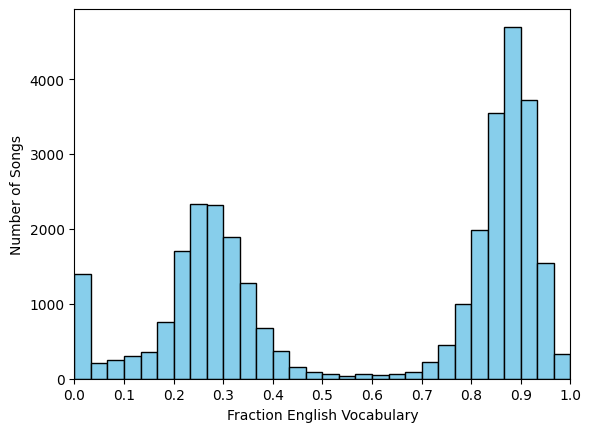

In [23]:
# compare intersection of vocab to the size of the vocab

df_removed_same_lyrics_mult_genre['frac_english'] = [len(vocab.intersection(web2lowerset))/len(vocab) for vocab in df_removed_same_lyrics_mult_genre['song_vocab'].to_list()]

import matplotlib.pyplot as plt

fig, ax = plt.subplots()
df_removed_same_lyrics_mult_genre['frac_english'].plot.hist(bins=30, edgecolor='black', color='skyblue',)
plt.xlabel("Fraction English Vocabulary")
plt.ylabel("Number of Songs")
plt.xticks(np.arange(0, 1.1, 0.1))
ax.set_xlim(0,1.0)
plt.show()

In [24]:
# keep songs that have over 75% english

df_english = df_removed_same_lyrics_mult_genre[df_removed_same_lyrics_mult_genre['frac_english'] >= 0.75]

df_english.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17100 entries, 0 to 40582
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              17100 non-null  object 
 1   lyrics          17100 non-null  object 
 2   track_genre     17100 non-null  object 
 3   lyric_count     17100 non-null  int64  
 4   song_vocab      17100 non-null  object 
 5   lyrics_cleaned  17100 non-null  object 
 6   frac_english    17100 non-null  float64
dtypes: float64(1), int64(1), object(5)
memory usage: 1.0+ MB


In [126]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split

# 1. Prepare your data
# texts: list of strings (e.g., lyrics or document snippets)
# labels: corresponding categories (e.g., 'pop', 'rock', 'rap')
X_train, X_test, y_train, y_test = train_test_split(df_english['lyrics'], df_english['track_genre'], test_size=0.2)

# 2. Create the pipeline
# TfidfVectorizer converts text to a matrix of TF-IDF features
# MultinomialNB is a common, fast classifier for text
model = make_pipeline(TfidfVectorizer(stop_words='english'), MultinomialNB())

# 3. Train the model
model.fit(X_train, y_train)

# 4. Predict
predictions = model.predict(X_test)


In [127]:
compare = pd.DataFrame({
    'test_lyrics' : X_test,
    'test_genre': y_test,
    'predicted_genre': predictions
})

In [128]:
correct= compare[compare['predicted_genre']==compare['test_genre']]

In [129]:
df_english['track_genre'].unique()

array(['afrobeat', 'alt-rock', 'alternative', 'ambient', 'anime',
       'black-metal', 'bluegrass', 'blues', 'breakbeat', 'cantopop',
       'chicago-house', 'children', 'chill', 'classical', 'club',
       'comedy', 'country', 'dance', 'dancehall', 'death-metal',
       'deep-house', 'detroit-techno', 'disco', 'disney', 'drum-and-bass',
       'dub', 'dubstep', 'edm', 'electro', 'electronic', 'emo', 'folk',
       'funk', 'garage', 'gospel', 'goth', 'grindcore', 'groove',
       'grunge', 'guitar', 'happy', 'hard-rock', 'hardcore', 'hardstyle',
       'heavy-metal', 'hip-hop', 'honky-tonk', 'house', 'idm',
       'indie-pop', 'indie', 'industrial', 'j-dance', 'j-idol', 'j-pop',
       'j-rock', 'jazz', 'k-pop', 'kids', 'latin', 'latino', 'malay',
       'mandopop', 'metal', 'metalcore', 'minimal-techno', 'mpb',
       'new-age', 'opera', 'pagode', 'party', 'piano', 'pop-film', 'pop',
       'power-pop', 'progressive-house', 'psych-rock', 'punk-rock',
       'punk', 'r-n-b', 'reggae',

In [112]:
df_genre_master = pd.read_csv('./genres.csv')

In [ ]:
'''
import re
def clean(x):
    clean_text = re.sub(r'\s+', '_', x)
    return re.sub(r'[^\w]',"",clean_text).lower()

df_genre_master['genre'] = df_genre_master['genre'].apply(clean)
df_genre_master['subgenre'] = df_genre_master['subgenre'].apply(clean)
df_english['track_genre']=df_english['track_genre'].apply(clean)

mapping = df_genre_master.set_index("subgenre")['genre']
'''

C:\Users\conno\AppData\Local\Temp\ipykernel_12756\3481297957.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_english['track_genre']=df_english['track_genre'].apply(clean)


In [ ]:
# df_english.to_csv('./cleaned_songs_with_lyrics.csv')